Playing around with PyTorch MRI datasets and image segmentation.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time

from medsegbench import Promise12MSBench
from scipy.ndimage import distance_transform_edt

import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large

Data loading and inspection

In [2]:
# Load Promise12 MRI prostate segmentation dataset from MedSegBench
train_images = Promise12MSBench(split="train", download=True, size=128)
val_images = Promise12MSBench(split="val", download=True, size=128)
# We only have access to a CPU, so choose 128x128 images to keep training time reasonable
# The model can be trained on higher-resolution images if you have access to a GPU

print(f"Training set size: {len(train_images)}")
print(f"Validation set size: {len(val_images)}")

Training set size: 1031
Validation set size: 147


In [6]:
# Display sample images from training data
# for i in range(2):
#     image, mask = train_images[i] # Image is a PIL Image, mask is a numpy array
    
#     print(f"Sample {i}: Image shape: {image.size}, Mask shape: {mask.shape}")
       
#     fig, axes = plt.subplots(1, 2, figsize=(10, 5))
#     axes[0].imshow(image, cmap='gray')
#     axes[0].set_title(f'MRI Image (Sample {i})')
#     axes[1].imshow(mask, cmap='gray')
#     axes[1].set_title(f'Segmentation Mask (Sample {i})')
    # plt.tight_layout()
    # plt.show()

In [30]:
# Currently we have training and validation data in the form of PIL images and numpy array masks
# Let's get ready to train a model by converting them to tensors

class MRIDataset(Dataset):
    def __init__(self, base_dataset, eps=1e-5, normalize=True):
        self.base_dataset = base_dataset
        self.eps = eps
        self.normalize = normalize

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx]
        # Convert PIL image to array and normalize
        image = image.convert("L")  # Ensure grayscale
        image = np.array(image, dtype=np.float32)

        if self.normalize:
            # z-score per slice - normalize intensity to zero mean and unit variance. Add eps to avoid divide by zero
            image = (image - image.mean()) / (image.std() + self.eps)

        # Convert image to tensors and add channel dimension
        image = torch.from_numpy(image).unsqueeze(0)

        # Convert mask to binary: any non-zero value becomes 1 (as float for BCE loss)
        mask = torch.tensor((mask > 0).astype(np.float32), dtype=torch.float32).unsqueeze(0)
        return image, mask
    
# Wrap the datasets
train_dataset = MRIDataset(train_images)
val_dataset = MRIDataset(val_images)

# Create dataloaders - this is where we set batch size and shuffling
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

Model definition and initialization

In [4]:
# Let's set up a simple UNet model for segmentation
class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Define the convoltuional layers, including batch normalization and ReLU activation at each step
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        
        # Apply a few encoding layers with pooling
        self.enc1 = conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = conv_block(64, 128)
        
        # Decode back to a single channel using convolutions as well
        # self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = conv_block(128 + 64, 64)
        # self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = conv_block(64 + 32, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)

    # Apply each block defined above in sequence
    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        b = self.bottleneck(p2)

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

model = SimpleUNet()

# Check the properties of the model such as the number of tunable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total tunable parameters in the model: {total_params}")

Total tunable parameters in the model: 472257


In [4]:
# Loss function components

# Binary cross-entropy loss with logits
# pos_weight > 1 gives more weight to positive class (prostate), helping with class imbalance
# bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]))

def dice_loss(logits, target, eps=1e-7):
    """
    MEASURE OF OVERLAP BETWEEN TWO SAMPLES. IT RANGES FROM 0 TO 1, WHERE 1 MEANS PERFECT OVERLAP AND 0 MEANS NO OVERLAP
     
    logits: (B, 1, H, W) raw outputs
    target: (B, 1, H, W) binary masks
    eps: small constant to avoid division by zero
    """
    prob = logits.sigmoid()
    prob   = prob.view(prob.size(0), -1)
    target = target.view(target.size(0), -1)
    intersection = (prob * target).sum(dim=1) # Implement dice loss per-sample (sum over specific dimension)
    union = prob.sum(dim=1) + target.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean() # Subtract from 1 to convert to a loss (we want to maximize dice)


### BOUNDARY-SPECIFIC LOSS FUNCTION CONTRIBUTIONS ###

# Start with a function that maps the distance to the boundary of each pixel given the mask
def distance_transform(mask):
    """
    DISTANCE TRANSFORM SEPARATELY FOR INSIDE AND OUTSIDE OF THE MASK, WHICH CAN BE USED TO CONSTRUCT THE SIGNED DISTANCE MAP

    mask_np: (H, W) binary {0,1}
    returns: (H, W) tuple of (distance outside, distance inside)
    """

    fg_dt = distance_transform_edt(mask == 0)
    bg_dt = distance_transform_edt(mask == 1)
    return fg_dt, bg_dt  # outside DT, inside DT


def signed_distance_map(mask):
    """
    MAPS EACH PIXEL TO THE NEAREST BOUNDARY OF THE MASK, WITH SIGN INDICATING INSIDE/OUTSIDE
    
    mask_np: (H, W) binary {0,1}
    returns: (H, W) signed distance map (positive outside, negative inside)
    """
    fg_dt, bg_dt = distance_transform(mask)
    sdf = fg_dt - bg_dt
    return sdf.astype(np.float32)


def boundary_loss_from_logits(logits, sdf, max_dist=20.0):
    """
    BOUNDARY LOSS GIVEN LOGITS (WHICH ARE THE RAW MODEL OUTPUTS) AND THE SIGNED DISTANCE MAP
    
    logits: (B, 1, H, W) raw outputs
    sdf:    (B, 1, H, W) signed distance map (float)
    max_dist: maximum distance from boundary to consider for normalization (so pixel far from the boundary do not dominate the loss)
    """
    probs = torch.sigmoid(logits)
    sdf = torch.clamp(sdf, -max_dist, max_dist) / max_dist  # now in [-1, 1]
    # boundary loss is mean of p(x) * sdf(x)
    return torch.mean(probs * sdf)


def boundary_band_loss(logits, target, sdf, max_dist=20.0):
    """
    BOUNDARY THAT EMPHASIZES ERRORS NEAR THE BOUNDARY, WHICH IS WHERE THE ISSUES TEND TO BE
    
    logits: (B, 1, H, W) raw outputs
    sdf:    (B, 1, H, W) signed distance map (float)
    max_dist: maximum distance from boundary to consider for normalization (so pixel far from the boundary do not dominate the loss)
    """
    probs = torch.sigmoid(logits)
    # weights high near boundary (distance ~0), low far away
    w = 1.0 - torch.clamp(torch.abs(sdf), 0, max_dist) / max_dist  # in [0,1]
    # focus on mistakes near boundary
    return torch.mean(w * torch.abs(probs - target))



def hausdorff_dt_loss(logits, targets, fg_dt, bg_dt):
    """
    HAUSDORFF DISTANCE-BASED LOSS THAT PENALIZES FALSE POSITIVES AND FALSE NEGATIVES BASED ON THEIR DISTANCE TO THE TRUE BOUNDARY.
    GOOD AT ADDRESSING WHEN "CHUNKS" OF THE SEGMENTATION ARE MISSING OR EXTRA.

    logits: (B,1,H,W)
    targets:   (B,1,H,W) binary mask
    fg_dt:  (B,1,H,W) distance-transform outside the foreground (FN penalty field)
    bg_dt:  (B,1,H,W) distance-transform inside the foreground (FP penalty field)
    """
    probs = torch.sigmoid(logits)

    # Convert targets to numpy for distance transform calculations
    # targets = targets.detach().cpu().numpy()

    # false positives: predict 1 where targets = 0
    fp = probs * (1 - targets)
    # false negatives: predict 0 where targets = 1
    fn = (1 - probs) * targets

    # Convert distance map numpy arrays to tensors
    fg_dt = torch.tensor(fg_dt, dtype=torch.float32)
    bg_dt = torch.tensor(bg_dt, dtype=torch.float32)
    
    loss_fp = (fp * fg_dt).mean()
    loss_fn = (fn * bg_dt).mean()

    return loss_fp + loss_fn


# Combine BCE, Dice, and Boundary losses
def combined_loss(logits, targets, pos_weight=1.0, bce_weight=1.0, dice_weight=1.0, boundary_weight=1.0):
    """ COMBINATION OF DIFFERENT CONTRIBUTIONS TO THE LOSS FUNCTION WITH WEIGHTS SPECIFIED """
    bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
    
    bce = bce_loss(logits, targets)
    dice = dice_loss(logits, targets)

    fg_dt, bg_dt = distance_transform(targets.detach().cpu().numpy().squeeze(1))  # (B,H,W) numpy arrays
    bndry_loss = hausdorff_dt_loss(logits, targets, fg_dt, bg_dt)

    # sdf = fg_dt - bg_dt  # (B,H,W) signed distance map
    # bndry_loss = boundary_band_loss(logits, targets, sdf)

    return bce_weight * bce + dice_weight * dice + boundary_weight * bndry_loss


Training

In [8]:
# Set up the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 10
start_time = time.time()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, masks in train_loader:
        optimizer.zero_grad() # Reset gradients at each step

        outputs = model(images) # Calculate model outputs

        # Update weight of boundary loss term based on a schedule
        bdy_weight = min(1.0, epoch/5) # Works itself up to 1 over first 5 epochs, since earlier on it is better to focus on getting the overall shape right before heavily penalizing boundary errors
    
        loss = combined_loss(outputs, masks, boundary_weight=bdy_weight)
        loss.backward() # Differentiate loss function
        optimizer.step() # Update model parameters
        
        running_loss += loss.item() # Accumulate loss from each image
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    training_time = time.time() - start_time
    print(f"Total time: {int(training_time // 60)}m{int(training_time % 60)}s")

# Save the trained model
torch.save(model.state_dict(), 'new_model.pth')

Epoch 1, Loss: 0.1901026835808387
Total time: 2m25s
Epoch 2, Loss: 0.17371952212773836
Total time: 4m51s
Epoch 3, Loss: 0.1744951292872429
Total time: 7m2s
Epoch 4, Loss: 0.1641712268957725
Total time: 9m15s
Epoch 5, Loss: 0.16135345915189156
Total time: 11m29s
Epoch 6, Loss: 0.16883768336131022
Total time: 13m30s


KeyboardInterrupt: 

Evaluation and visualization

In [6]:
# Load the model

model = SimpleUNet()
model.load_state_dict(torch.load('./prostate_unet.pth'))

<All keys matched successfully>

In [7]:
# Evaluate the model on training and validation data

model.eval()

# Initialize the accuracy and loss accumulators, including individual loss components for validation set
# train_loss = 0.0
# running_accuracy_train = 0.0
val_loss = 0.0
val_bce, val_dice, val_bndry = 0.0, 0.0, 0.0
running_accuracy_val = 0.0

with torch.no_grad(): # Since we are not training, no need to calculate grad
    # for images, masks in train_loader:
    #     outputs = model(images)
    #     sdf = torch.stack([torch.tensor(signed_distance_map(mask.squeeze().numpy())) for mask in masks]).unsqueeze(1)
    #     loss = combined_loss(outputs, masks)
    #     train_loss += loss.item() # Loss function on training set

    #     # We want to calculate accuracy as well
    #     # The outputs are logits, apply sigmoid and threshold at 0.5
    #     predicted = torch.sigmoid(outputs).float()
    #     predicted = (predicted > 0.5).squeeze(1).float()  # Binarize predictions
    #     correct = (predicted == masks.squeeze(1)).sum().item()
    #     total = masks.numel()
    #     accuracy = correct / total
    #     running_accuracy_train += accuracy

    for images, masks in val_loader:
        outputs = model(images)
        sdf = torch.stack([torch.tensor(signed_distance_map(mask.squeeze().numpy())) for mask in masks]).unsqueeze(1)
        
        # Calculate individual loss components for analysis
        bce = bce_loss(outputs, masks)
        val_bce += bce.item()
        dice = dice_loss(outputs, masks)
        val_dice += dice.item()
        fg_dt, bg_dt = distance_transform(masks.detach().cpu().numpy().squeeze(1))
        bndry_loss = hausdorff_dt_loss(outputs, masks, fg_dt, bg_dt)
        val_bndry += bndry_loss.item()
        
        # Overall loss
        loss = combined_loss(outputs, masks)
        val_loss += loss.item() # Loss function on validation set

        # We want to calculate accuracy as well
        # The outputs are logits, apply sigmoid and threshold at 0.5
        predicted = torch.sigmoid(outputs).float()
        predicted = (predicted > 0.5).squeeze(1).float()  # Binarize predictions
        correct = (predicted == masks.squeeze(1)).sum().item()
        total = masks.numel()
        accuracy = correct / total
        running_accuracy_val += accuracy   

# print(f"Training Loss: {train_loss/len(train_loader):.4f}")
# # Divide summed accuracy by number of batches to get overall accuracy
# train_accuracy = running_accuracy_train / len(train_loader)
# print(f"Training Accuracy: {train_accuracy*100:.2f}%")

print(f"Validation Loss: {val_loss/len(val_loader):.4f}")
print(f"Validation BCE Loss: {val_bce/len(val_loader):.4f}")
print(f"Validation Dice Loss: {val_dice/len(val_loader):.4f}")
print(f"Validation Boundary Loss: {val_bndry/len(val_loader):.4f}")

val_accuracy = running_accuracy_val / len(val_loader)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

Validation Loss: 0.2001
Validation BCE Loss: 0.0297
Validation Dice Loss: 0.1525
Validation Boundary Loss: 0.0179
Validation Accuracy: 99.21%


NameError: name 'model' is not defined

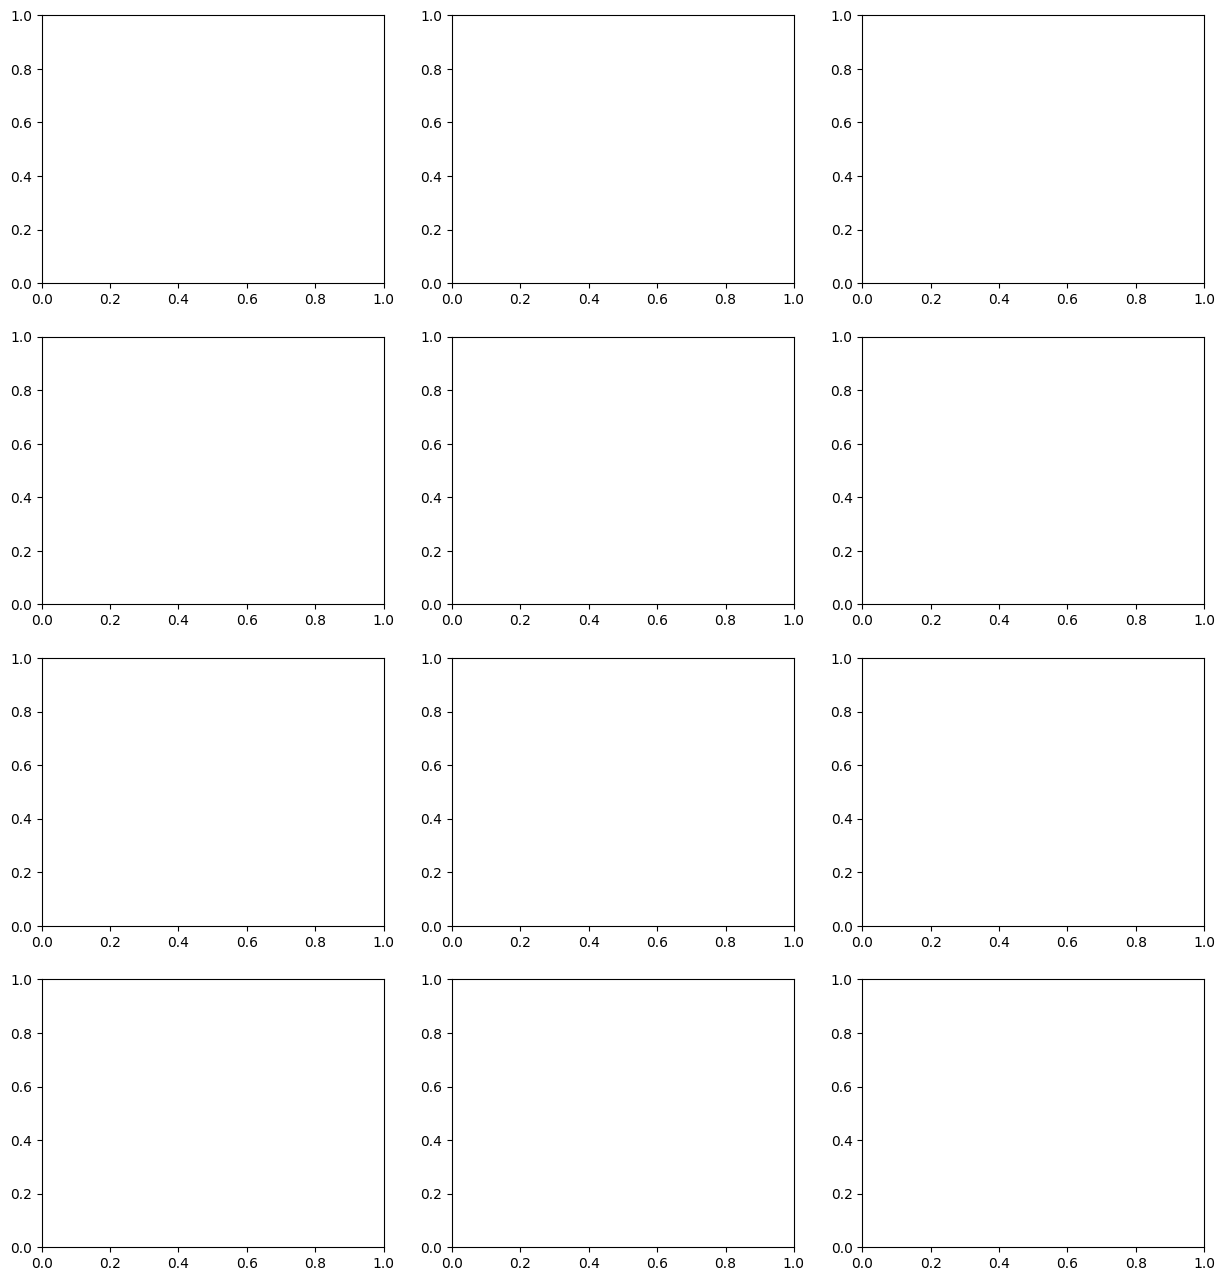

In [25]:
# Visualize predictions on validation set
num_samples = 4

fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))

with torch.no_grad():
    for idx in range(num_samples):
        image, mask = val_dataset[idx]
        
        # Add batch dimension and get prediction
    
        image_batch = image.unsqueeze(0)
        output = model(image_batch)
        
        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        predicted_mask = torch.sigmoid(output).squeeze(0).squeeze(0).numpy()
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

        # Convert to numpy for display
        image_np = image.squeeze(0).numpy()
        mask_np = mask.squeeze(0).numpy()
        
        # Display
        axes[idx, 0].imshow(image_np, cmap='gray')
        axes[idx, 0].set_title(f'Image {idx}')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(mask_np, cmap='gray')
        axes[idx, 1].set_title(f'Ground Truth {idx}')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(predicted_mask, cmap='gray')
        axes[idx, 2].set_title(f'Predicted {idx}')
        axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Now let's go back to the training step by try to emply transfer learning. We'll load in a pre-trained network, do a quick and dirty replacement of the last layer with softmax for per pixel classification. Then when we train we'll limit backprop to only the final layer, since we have limited processing capacity and do not want to mess with the pretrained layers

# The pre-trained model will expect an RGB image--we'll modify it to accept a single-channel greyscale image

def build_simple_seg_model():
    # 1) Load pretrained model
    model_pretrained = deeplabv3_mobilenet_v3_large(weights="DEFAULT")

    # 2) Replace first conv to accept grayscale 
    # Probe the backbone to find the first 2-d convolutional layer that takes in a three-channel input. It's this layer that we'll modify to take in a single channel for greyscale images
    target_name, first_conv = None, None
    for name, module in model_pretrained.backbone.named_modules():
        if isinstance(module, nn.Conv2d) and module.in_channels == 3:
            target_name, first_conv = name, module
            break
    if first_conv is None:
        raise RuntimeError("Could not find a 3-channel Conv2d in the backbone.")

    # Build the new convolutional layer with all the same features as that of the pretrained model, but with only a single input channel and weights given as the average of the three input channels of the pretrained model
    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=first_conv.out_channels,
        kernel_size=first_conv.kernel_size,
        stride=first_conv.stride,
        padding=first_conv.padding,
        dilation=first_conv.dilation,
        groups=1,  # first layer shouldn't be depthwise; keep standard conv
        bias=(first_conv.bias is not None),
        padding_mode=getattr(first_conv, "padding_mode", "zeros"),
    )
    with torch.no_grad():
        new_conv.weight.copy_(first_conv.weight.mean(dim=1, keepdim=True))
        if first_conv.bias is not None and new_conv.bias is not None:
            new_conv.bias.copy_(first_conv.bias)


    # Set it back into the backbone at the same path
    parent = model_pretrained.backbone
    parts = target_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], new_conv)

    # 3) Replace classifier last layer → 1 output channel (binary segmentation)
    in_ch = model_pretrained.classifier[-1].in_channels
    model_pretrained.classifier[-1] = nn.Conv2d(in_ch, 1, kernel_size=1)

    # 4) Freeze everything except the final conv
    for p in model_pretrained.parameters():
        p.requires_grad = False
    # Unfreeze the last few blocks of the backbone
    for name, p in model_pretrained.named_parameters():
        if "backbone" in name and ("5" in name or "6" in name):
            p.requires_grad = True
    # Unfreeze the last few layers of the classifier head
    classifier_modules = list(model_pretrained.classifier.children())
    for m in classifier_modules[-4:]:
        for p in m.parameters():
            p.requires_grad = True

    return model_pretrained

# Usage:
# model = build_simple_seg_model()
# logits = model(images)['out']   # shape: (B,1,H,W)

In [39]:
pretrained_model = build_simple_seg_model()
# Check the properties of the model such as the number of tunable parameters
total_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f"Total tunable parameters in the model: {total_params}")
optimizer = torch.optim.Adam(
    [p for p in pretrained_model.parameters() if p.requires_grad],
    lr=1e-3,
)

Total tunable parameters in the model: 2393145


In [40]:

# Train the transfer learning model
num_epochs = 10
start_time = time.time()
for epoch in range(num_epochs):
    pretrained_model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        # images = images.to(device)      # (B,1,H,W)
        # masks  = masks.to(device)       # (B,1,H,W)

        optimizer.zero_grad()

        # forward pass
        logits = pretrained_model(images)['out']   # (B,1,H,W)

        # Schedule for the weight of the boundary term in the loss function
        bdy_weight = min(1.0, epoch/5) # Works itself up to 1 over first 5 epochs, since earlier on it is better to focus on getting the overall shape right before heavily penalizing boundary errors
    
        # combined BCE and DICE loss
        loss = combined_loss(
            logits, masks,
            pos_weight=3.0,
            bce_weight=1.0,
            dice_weight=1.0,
            boundary_weight=bdy_weight
        )

        # Backward pass (only last layer has gradients)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)


    # ---- validation ----
    pretrained_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            # images = images.to(device)
            # masks  = masks.to(device)

            logits = pretrained_model(images)['out']

            bdy_weight = min(1.0, epoch/5)
            loss = combined_loss(
                logits, masks,
                pos_weight=3.0,
                bce_weight=1.0,
                dice_weight=1.0,
                boundary_weight=bdy_weight
            )
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    training_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs}  "
          f"Train Loss: {avg_train_loss:.4f}  "
          f"Val Loss: {avg_val_loss:.4f}\n"
          f"Total time: {int(training_time // 60)}m{int(training_time % 60)}s")

# Save the trained model
torch.save(pretrained_model.state_dict(), 'new_model_transfer.pth')

Epoch 1/10  Train Loss: 0.7658  Val Loss: 0.5059
Total time: 0m46s
Epoch 2/10  Train Loss: 0.4001  Val Loss: 0.4632
Total time: 1m35s
Epoch 3/10  Train Loss: 0.3347  Val Loss: 0.3704
Total time: 2m24s
Epoch 4/10  Train Loss: 0.3048  Val Loss: 0.3350
Total time: 3m11s
Epoch 5/10  Train Loss: 0.2837  Val Loss: 0.3526
Total time: 3m55s
Epoch 6/10  Train Loss: 0.2647  Val Loss: 0.3325
Total time: 4m39s
Epoch 7/10  Train Loss: 0.2530  Val Loss: 0.3203
Total time: 5m25s
Epoch 8/10  Train Loss: 0.2481  Val Loss: 0.3111
Total time: 6m6s
Epoch 9/10  Train Loss: 0.2317  Val Loss: 0.3128
Total time: 6m44s
Epoch 10/10  Train Loss: 0.2217  Val Loss: 0.2577
Total time: 7m30s


In [7]:
# Load the model trained with transfer learning

pretrained_model = build_simple_seg_model()
pretrained_model.load_state_dict(torch.load('./new_model_transfer.pth'))

<All keys matched successfully>

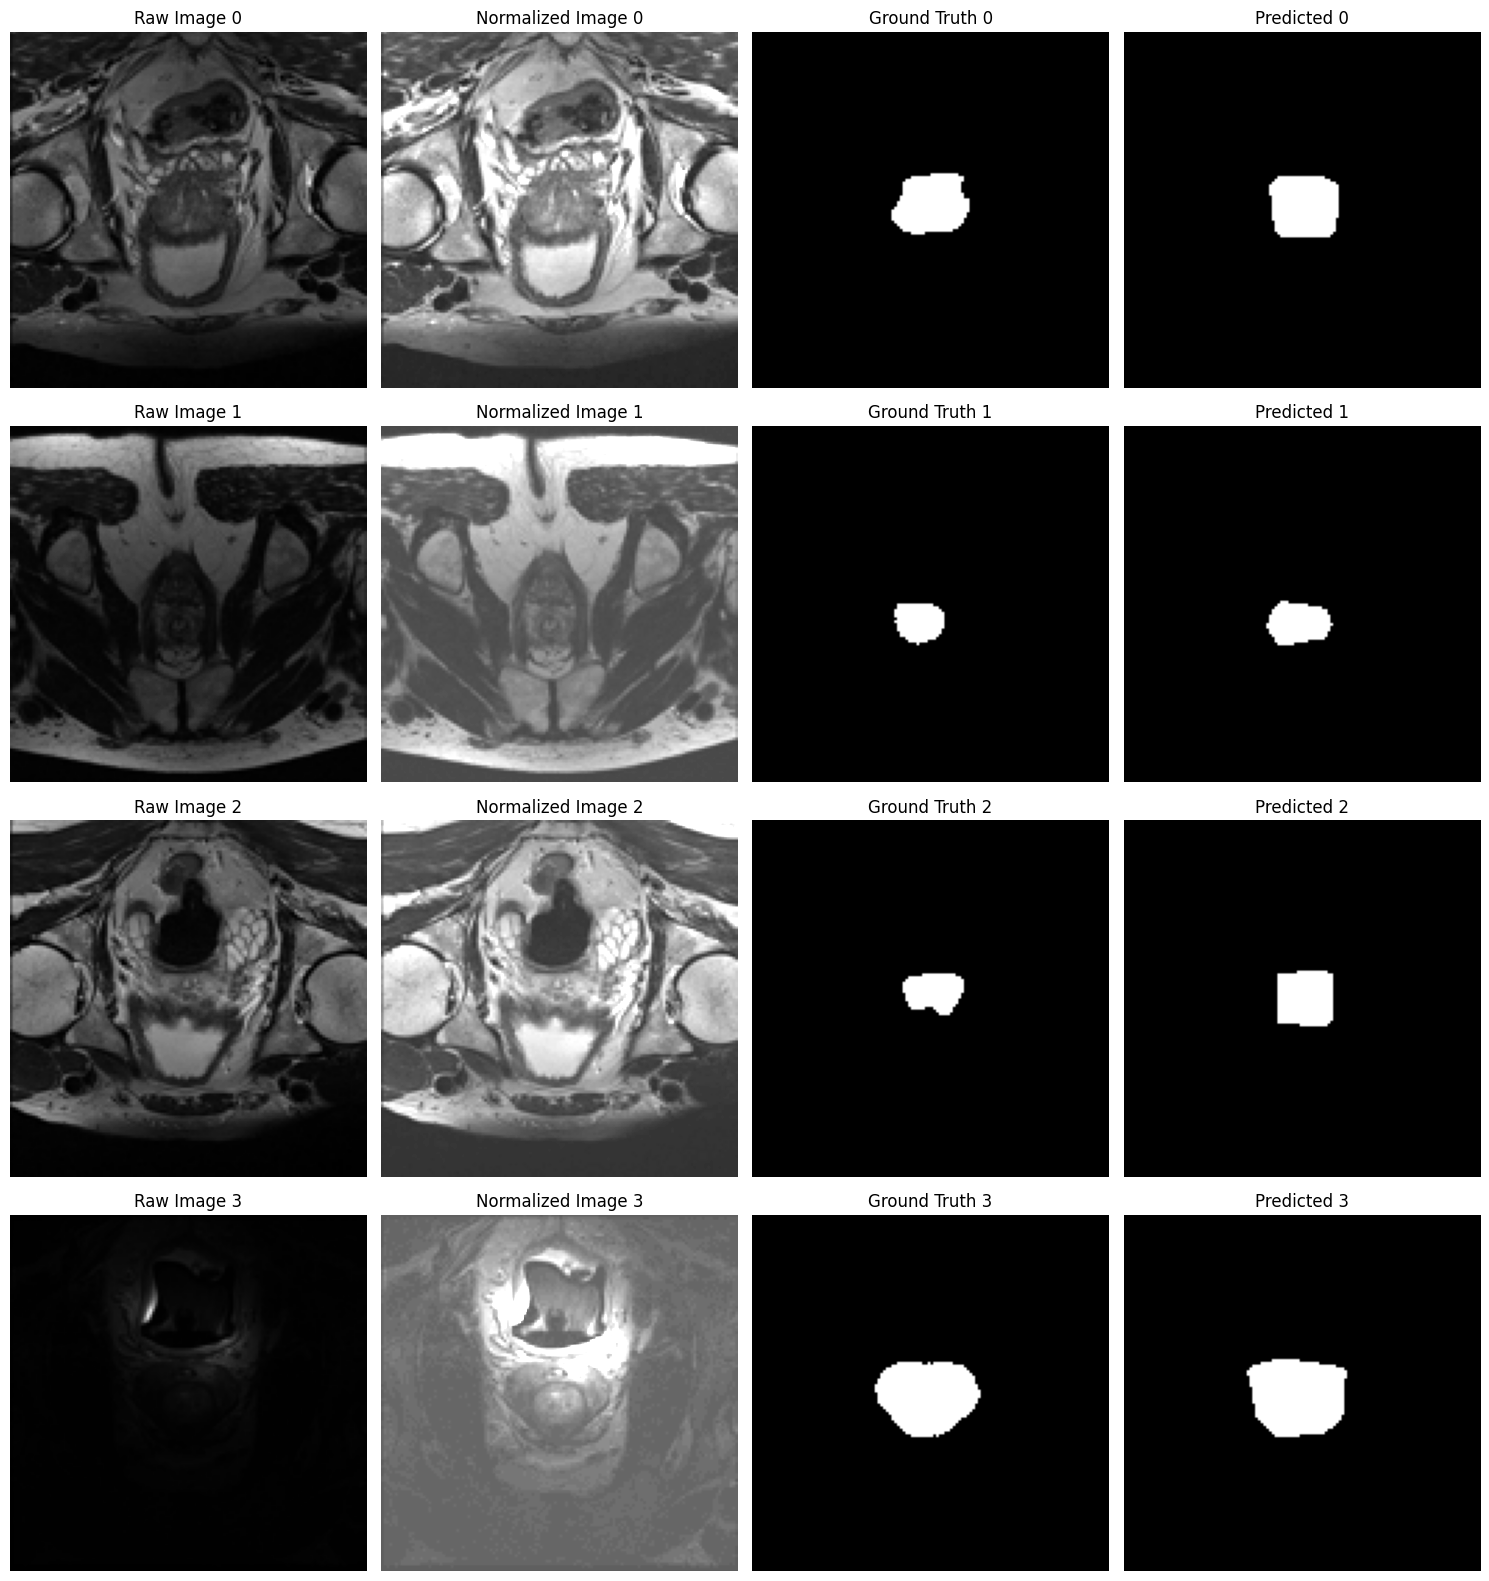

In [41]:

# Visualize predictions on validation set
num_samples = 4

fig, axes = plt.subplots(num_samples, 4, figsize=(15, 4 * num_samples))

pretrained_model.eval()
with torch.no_grad():
    for idx in range(num_samples):
        image, _ = val_dataset[idx]
        
        # Add batch dimension and get prediction
    
        image_batch = image.unsqueeze(0)
        out_dict = pretrained_model(image_batch)
        output = out_dict['out']

        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        predicted_mask = torch.sigmoid(output).squeeze(0).squeeze(0).numpy()
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)
        
        # Grab raw (unnormalized) PIL image from the dataset for display purposes
        raw_pil, mask = val_dataset.base_dataset[idx]     # PIL.Image
        raw_np = np.array(raw_pil.convert("L"))        # (H, W) uint8
        mask_np = np.array(mask)

        image_np = image.numpy().squeeze(0)

        # Display
        axes[idx, 0].imshow(raw_np, cmap='gray', vmin=0, vmax=255)
        axes[idx, 0].set_title(f'Raw Image {idx}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(image_np, cmap='gray',vmin=-2, vmax=2)
        axes[idx, 1].set_title(f'Normalized Image {idx}')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(mask_np, cmap='gray')
        axes[idx, 2].set_title(f'Ground Truth {idx}')
        axes[idx, 2].axis('off')
        
        axes[idx, 3].imshow(predicted_mask, cmap='gray')
        axes[idx, 3].set_title(f'Predicted {idx}')
        axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()
